# NutriMatch — Exploratory Data Analysis
### Data Scientist · Orang A: Nutrisi & Profil Pengguna

---

**Tujuan EDA ini:**
Memahami karakteristik data makanan dan profil pengguna, EDA ini menjawab tiga pertanyaan:
1. Bagaimana distribusi nutrisi makanan Indonesia yang ada di dataset?
2. Seberapa bersih data yang sudah kita miliki?
3. Apakah formula BMR/TDEE dan target makro menghasilkan nilai yang masuk akal?

**Dataset yang dianalisis:**
- `food_master_clean.csv` — 1.332 makanan Indonesia dengan kandungan nutrisi per 100g
- `user_profile_features_schema.csv` — 100 profil pengguna simulasi dengan fitur BMR/TDEE

---
## Setup

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Tema Warna
C_DARK      = '#1C2833'   # teks
C_MUTED     = '#717D7E'   # label sekunder, garis grid
C_HIGHLIGHT = '#2471A3'   # aksen tunggal — biru tua
C_NEUTRAL   = '#D5D8DC'   # bar/elemen non-fokus
C_ALERT     = '#CB4335'   # peringatan / anomali
C_OK        = '#1E8449'   # status bersih / positif

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.edgecolor'  : '#E5E7E9',
    'axes.grid'       : True,
    'grid.color'      : '#F2F3F4',
    'grid.linestyle'  : '-',
    'grid.linewidth'  : 0.8,
    'text.color'      : C_DARK,
    'axes.labelcolor' : C_DARK,
    'axes.titlecolor' : C_DARK,
    'xtick.color'     : C_MUTED,
    'ytick.color'     : C_MUTED,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
})

def add_subtitle(ax, text):
    """Tambahkan keterangan konteks di bawah judul grafik."""
    ax.text(0, 1.03, text, transform=ax.transAxes,
            fontsize=9.5, color=C_MUTED, va='bottom')

def add_insight_bar(fig, text, y=-0.04):
    """Strip insight di bawah figure — mudah dibaca audiens non-teknis."""
    fig.text(0.5, y, text, ha='center', va='bottom',
             fontsize=9.5, color=C_DARK,
             bbox=dict(facecolor='#EBF5FB', edgecolor='#AED6F1',
                       boxstyle='round,pad=0.5', alpha=0.9))

# Load dataset
fm = pd.read_csv('food_master_clean.csv')
up = pd.read_csv('user_profile_features_schema.csv')

print(f'food_master_clean          : {len(fm):,} baris × {fm.shape[1]} kolom')
print(f'user_profile_features_schema: {len(up)} baris × {up.shape[1]} kolom')

food_master_clean          : 1,332 baris × 11 kolom
user_profile_features_schema: 100 baris × 16 kolom


---
## EDA 01 — Distribusi Kalori & Korelasi Makronutrien

**Pertanyaan:** Seberapa beragam kalori makanan Indonesia? Makronutrien mana yang paling menentukan total kalori?

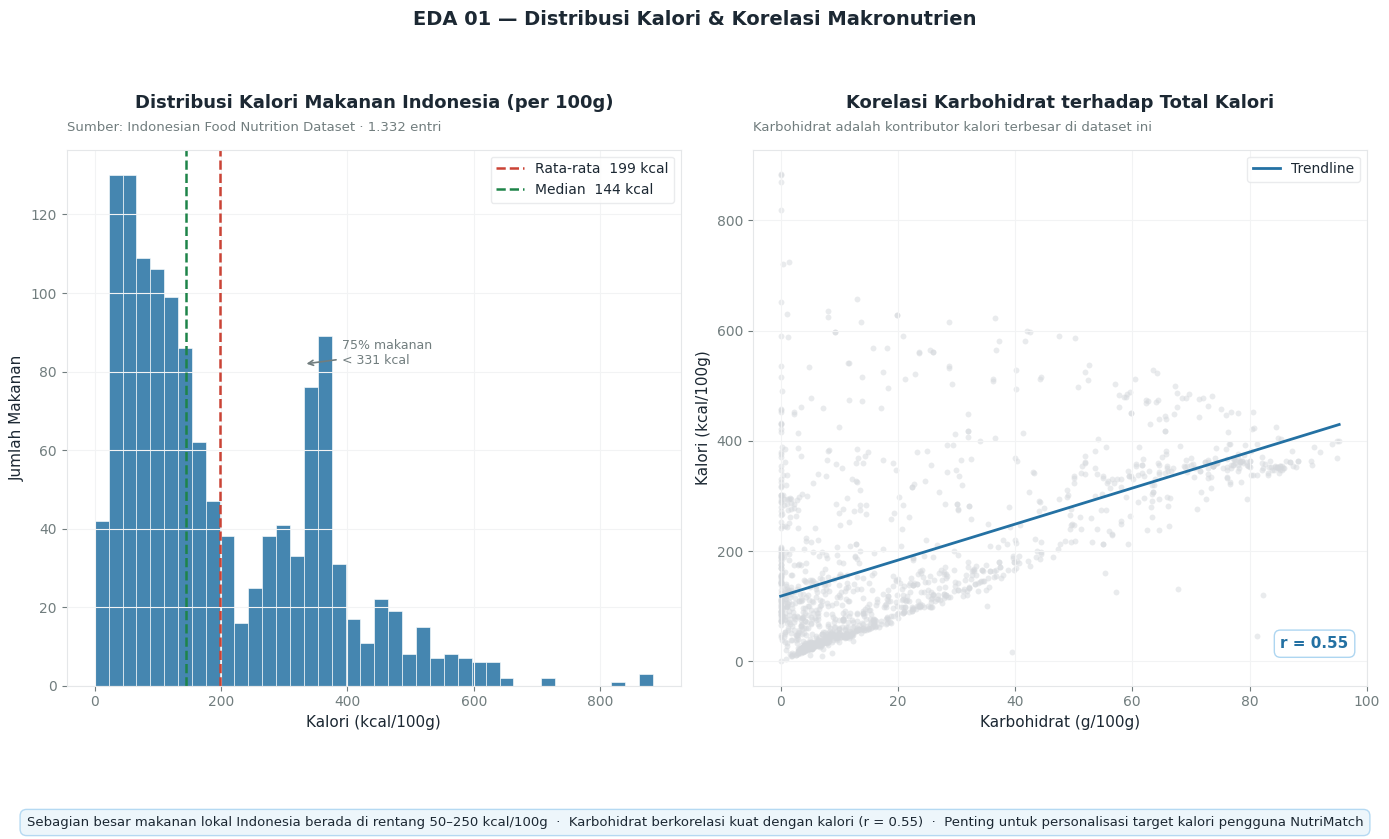

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('EDA 01 — Distribusi Kalori & Korelasi Makronutrien',
             fontsize=14, fontweight='bold', y=1.05)

# ── [Kiri] Histogram Kalori
axes[0].hist(fm['calories_100g'], bins=40,
             color=C_HIGHLIGHT, alpha=0.85, edgecolor='white', linewidth=0.5)

mean_cal   = fm['calories_100g'].mean()
median_cal = fm['calories_100g'].median()

axes[0].axvline(mean_cal,   color=C_ALERT, linestyle='--', linewidth=1.8,
                label=f'Rata-rata  {mean_cal:.0f} kcal')
axes[0].axvline(median_cal, color=C_OK,    linestyle='--', linewidth=1.8,
                label=f'Median  {median_cal:.0f} kcal')

axes[0].set_title('Distribusi Kalori Makanan Indonesia (per 100g)', fontweight='bold', pad=30)
axes[0].set_xlabel('Kalori (kcal/100g)')
axes[0].set_ylabel('Jumlah Makanan')
axes[0].legend(frameon=True, edgecolor='#E5E7E9')
add_subtitle(axes[0], 'Sumber: Indonesian Food Nutrition Dataset · 1.332 entri')

axes[0].annotate(
    f'75% makanan\n< {fm["calories_100g"].quantile(0.75):.0f} kcal',
    xy=(fm['calories_100g'].quantile(0.75), axes[0].get_ylim()[1]*0.6),
    xytext=(fm['calories_100g'].quantile(0.75)+60, axes[0].get_ylim()[1]*0.6),
    fontsize=9, color=C_MUTED,
    arrowprops=dict(arrowstyle='->', color=C_MUTED, lw=1.2)
)

# ── [Kanan] Scatter Carb vs Calorie
axes[1].scatter(fm['carbohydrate_100g'], fm['calories_100g'],
                color=C_NEUTRAL, alpha=0.5, s=18, linewidths=0)

m, b = np.polyfit(fm['carbohydrate_100g'], fm['calories_100g'], 1)
x_line = np.linspace(0, fm['carbohydrate_100g'].max(), 100)
axes[1].plot(x_line, m*x_line+b, color=C_HIGHLIGHT, linewidth=2, label='Trendline')

corr = fm['carbohydrate_100g'].corr(fm['calories_100g'])
axes[1].text(0.97, 0.07, f'r = {corr:.2f}',
             transform=axes[1].transAxes, ha='right',
             fontsize=11, fontweight='bold', color=C_HIGHLIGHT,
             bbox=dict(facecolor='white', edgecolor='#AED6F1', boxstyle='round,pad=0.4'))

axes[1].set_title('Korelasi Karbohidrat terhadap Total Kalori', fontweight='bold', pad=30)
axes[1].set_xlabel('Karbohidrat (g/100g)')
axes[1].set_ylabel('Kalori (kcal/100g)')
axes[1].legend(frameon=True, edgecolor='#E5E7E9')
add_subtitle(axes[1], 'Karbohidrat adalah kontributor kalori terbesar di dataset ini')

add_insight_bar(fig,
    'Sebagian besar makanan lokal Indonesia berada di rentang 50–250 kcal/100g  ·  '
    f'Karbohidrat berkorelasi kuat dengan kalori (r = {corr:.2f})  ·  '
    'Penting untuk personalisasi target kalori pengguna NutriMatch',
    y=-0.12)

plt.tight_layout()
plt.savefig('eda_01_calorie_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## EDA 02 — Top 15 Makanan: Sumber Protein & Lemak

**Pertanyaan:** Makanan apa yang paling kaya protein? Makanan apa yang harus diwaspadai karena kandungan lemak tinggi?

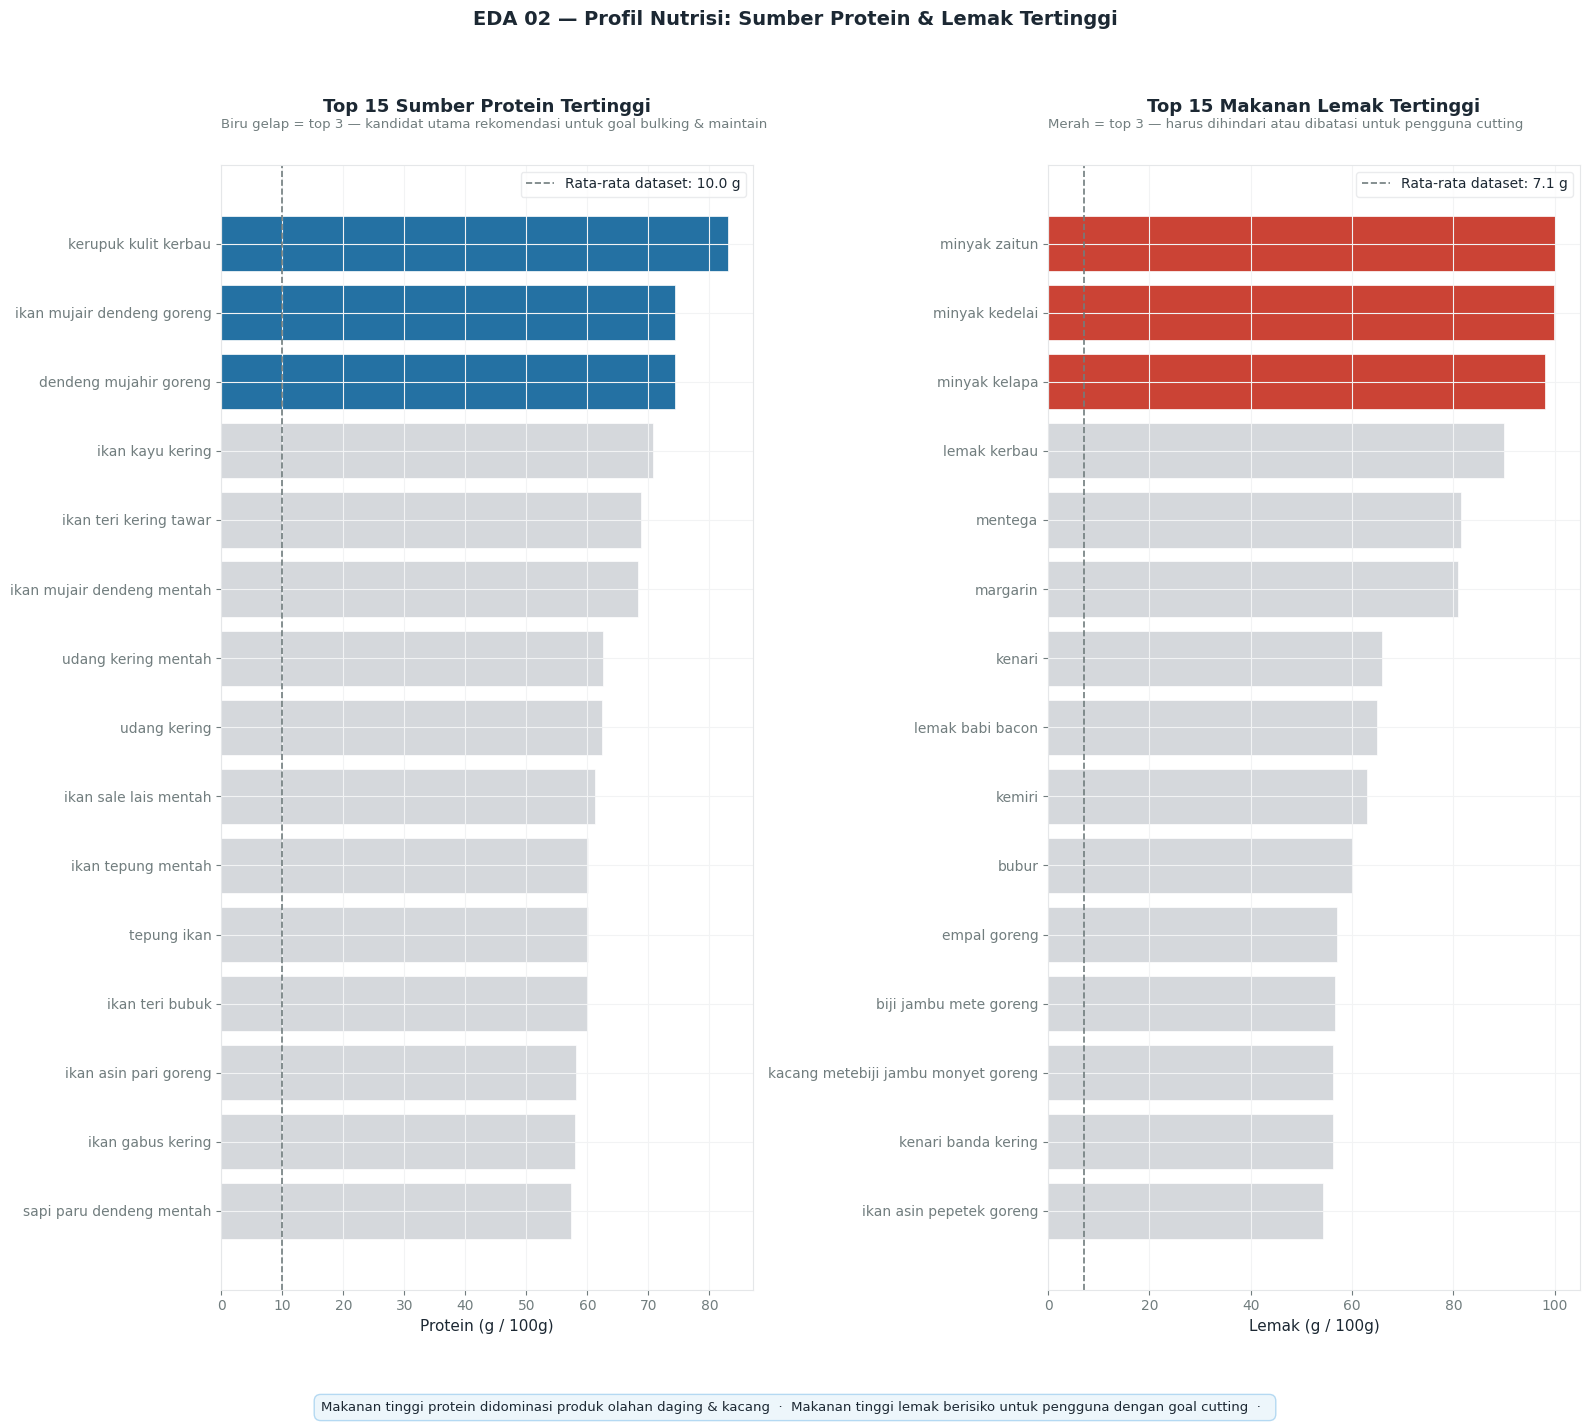

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 13))
fig.suptitle('EDA 02 — Profil Nutrisi: Sumber Protein & Lemak Tertinggi',
             fontsize=14, fontweight='bold', y=1.03)

# ── [Kiri] Top Protein
top_prot   = fm.nlargest(15, 'protein_100g')[['food_name','protein_100g']].sort_values('protein_100g')
colors_p   = [C_HIGHLIGHT if i >= 12 else C_NEUTRAL for i in range(15)]

axes[0].barh(top_prot['food_name'], top_prot['protein_100g'],
             color=colors_p, edgecolor='white', linewidth=0.5)
axes[0].axvline(fm['protein_100g'].mean(), color=C_MUTED, linestyle='--',
                linewidth=1.2, label=f'Rata-rata dataset: {fm["protein_100g"].mean():.1f} g')
axes[0].set_title('Top 15 Sumber Protein Tertinggi', fontweight='bold', pad=38)
axes[0].set_xlabel('Protein (g / 100g)')
axes[0].set_ylabel('')
axes[0].legend(frameon=True, edgecolor='#E5E7E9')
add_subtitle(axes[0], 'Biru gelap = top 3 — kandidat utama rekomendasi untuk goal bulking & maintain')

# ── [Kanan] Top Lemak
top_fat  = fm.nlargest(15, 'fat_100g')[['food_name','fat_100g']].sort_values('fat_100g')
colors_f = [C_ALERT if i >= 12 else C_NEUTRAL for i in range(15)]

axes[1].barh(top_fat['food_name'], top_fat['fat_100g'],
             color=colors_f, edgecolor='white', linewidth=0.5)
axes[1].axvline(fm['fat_100g'].mean(), color=C_MUTED, linestyle='--',
                linewidth=1.2, label=f'Rata-rata dataset: {fm["fat_100g"].mean():.1f} g')
axes[1].set_title('Top 15 Makanan Lemak Tertinggi', fontweight='bold', pad=38)
axes[1].set_xlabel('Lemak (g / 100g)')
axes[1].set_ylabel('')
axes[1].legend(frameon=True, edgecolor='#E5E7E9')
add_subtitle(axes[1], 'Merah = top 3 — harus dihindari atau dibatasi untuk pengguna cutting')

add_insight_bar(fig,
    'Makanan tinggi protein didominasi produk olahan daging & kacang  ·  '
    'Makanan tinggi lemak berisiko untuk pengguna dengan goal cutting  ·  ',
    y=-0.05)

plt.tight_layout()
plt.savefig('eda_02_top_foods.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## EDA 03 — Audit Kualitas Dataset

**Pertanyaan:** Seberapa bersih data yang akan digunakan? Berapa banyak entri yang perlu perhatian khusus dari AI Engineer?

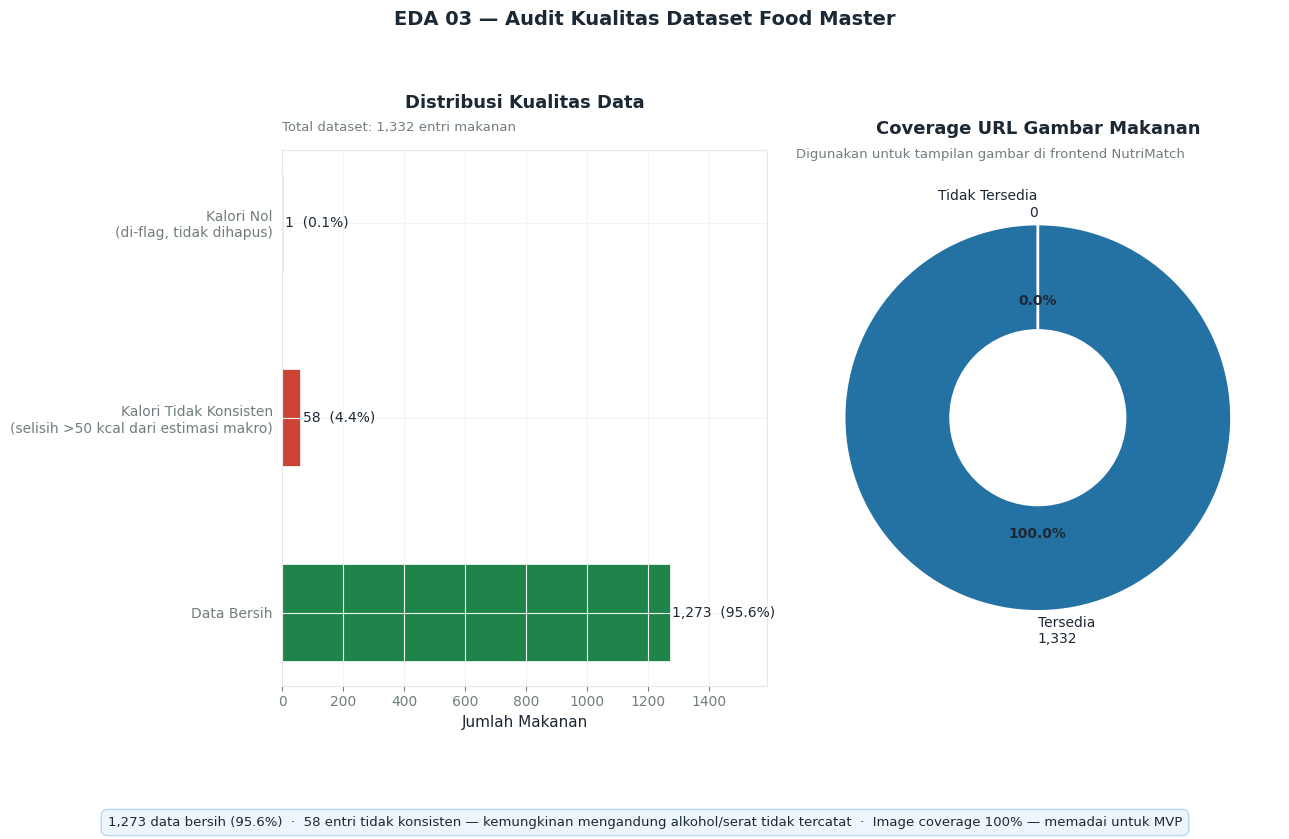

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('EDA 03 — Audit Kualitas Dataset Food Master',
             fontsize=14, fontweight='bold', y=1.05)

# ── [Kiri] Quality Breakdown
zero_cal  = int(fm['zero_calorie_flag'].sum())
incons    = int(fm['calorie_inconsistent_flag'].sum())
clean     = len(fm) - zero_cal - incons

cats   = ['Data Bersih',
          'Kalori Tidak Konsisten\n(selisih >50 kcal dari estimasi makro)',
          'Kalori Nol\n(di-flag, tidak dihapus)']
counts = [clean, incons, zero_cal]
colors = [C_OK, C_ALERT, C_MUTED]

bars = axes[0].barh(cats, counts, color=colors, edgecolor='white', linewidth=0.5, height=0.5)
axes[0].set_title('Distribusi Kualitas Data', fontweight='bold', pad=30)
axes[0].set_xlabel('Jumlah Makanan')
axes[0].set_xlim(0, max(counts)*1.25)
axes[0].tick_params(left=False)

for bar, val, pct in zip(bars, counts, [v/len(fm)*100 for v in counts]):
    axes[0].text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
                 f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)
add_subtitle(axes[0], f'Total dataset: {len(fm):,} entri makanan')

# ── [Kanan] Image Coverage Donut
has_img = int((fm['image_url'] != 'not_available').sum())
no_img  = len(fm) - has_img

wedges, texts, autotexts = axes[1].pie(
    [has_img, no_img],
    labels=[f'Tersedia\n{has_img:,}', f'Tidak Tersedia\n{no_img}'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[C_HIGHLIGHT, C_NEUTRAL],
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Coverage URL Gambar Makanan', fontweight='bold', pad=30)
add_subtitle(axes[1], 'Digunakan untuk tampilan gambar di frontend NutriMatch')

add_insight_bar(fig,
    f'{clean:,} data bersih ({clean/len(fm)*100:.1f}%)  ·  '
    f'{incons} entri tidak konsisten — kemungkinan mengandung alkohol/serat tidak tercatat  ·  '
    f'Image coverage {has_img/len(fm)*100:.0f}% — memadai untuk MVP',
    y=-0.12)

plt.tight_layout()
plt.savefig('eda_03_quality_audit.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## EDA 04 — Analisis Profil Pengguna: BMR, TDEE & Target Gizi

**Pertanyaan:** Apakah formula BMR/TDEE dan target makro menghasilkan nilai yang realistis dan terdistribusi wajar?

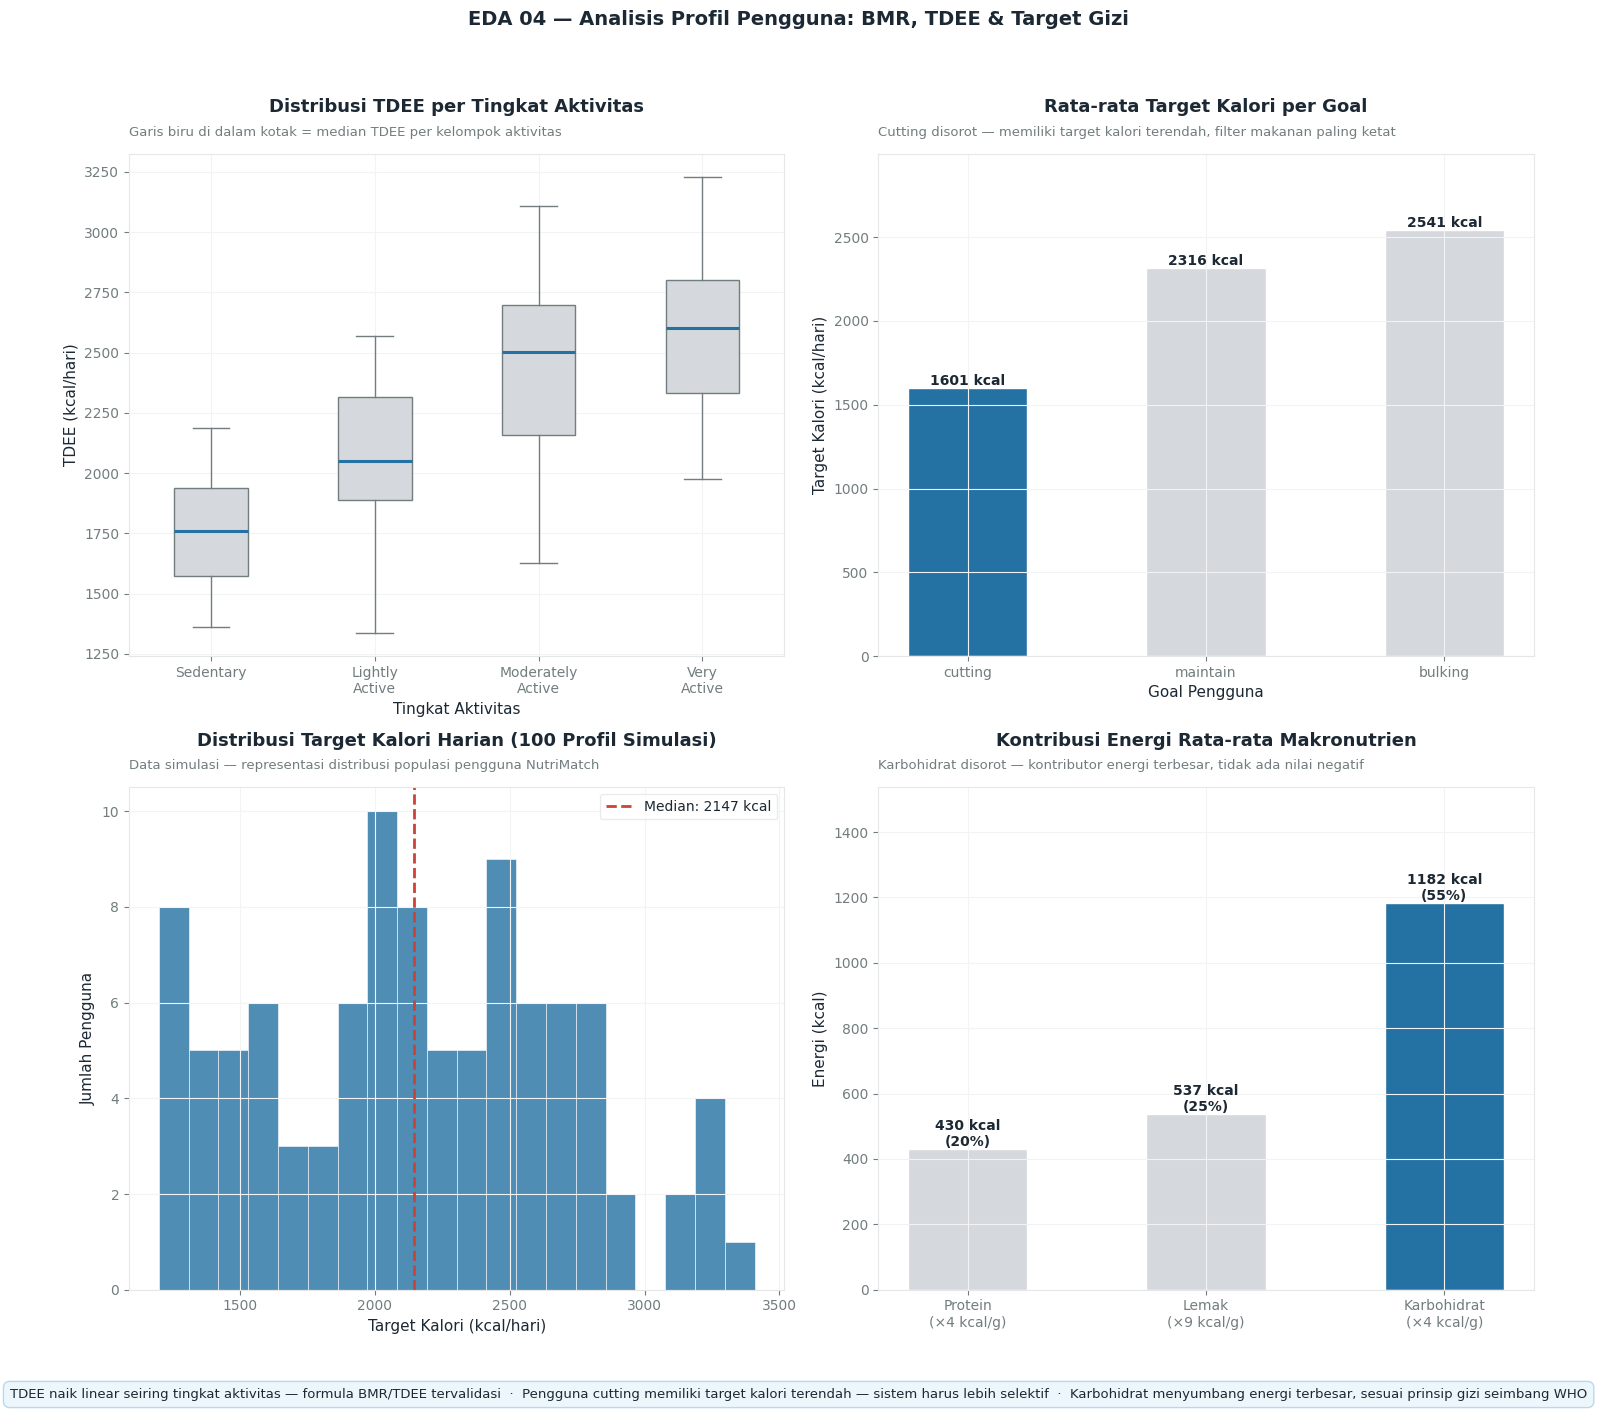

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.suptitle('EDA 04 — Analisis Profil Pengguna: BMR, TDEE & Target Gizi',
             fontsize=14, fontweight='bold', y=1.03)

activity_order = ['Sedentary','Lightly Active','Moderately Active','Very Active']

# ── [1] Boxplot TDEE per Activity Level
bp = axes[0,0].boxplot(
    [up[up['activity_level']==lvl]['tdee'].values for lvl in activity_order],
    labels=['Sedentary','Lightly\nActive','Moderately\nActive','Very\nActive'],
    patch_artist=True,
    medianprops=dict(color=C_HIGHLIGHT, linewidth=2.2),
    whiskerprops=dict(color=C_MUTED),
    capprops=dict(color=C_MUTED),
    flierprops=dict(marker='o', markerfacecolor=C_MUTED, markersize=4, alpha=0.5)
)
for patch in bp['boxes']:
    patch.set_facecolor(C_NEUTRAL)
    patch.set_edgecolor(C_MUTED)
axes[0,0].set_title('Distribusi TDEE per Tingkat Aktivitas', fontweight='bold', pad=30)
axes[0,0].set_xlabel('Tingkat Aktivitas')
axes[0,0].set_ylabel('TDEE (kcal/hari)')
add_subtitle(axes[0,0], 'Garis biru di dalam kotak = median TDEE per kelompok aktivitas')

# ── [2] Bar Rata-rata Target Kalori per Goal
goal_stats  = up.groupby('goal')['target_calorie'].mean().reindex(['cutting','maintain','bulking'])
bar_colors2 = [C_HIGHLIGHT, C_NEUTRAL, C_NEUTRAL]
bars2 = axes[0,1].bar(goal_stats.index, goal_stats.values,
                       color=bar_colors2, edgecolor='white', width=0.5)
for bar, val in zip(bars2, goal_stats.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, val+20,
                   f'{val:.0f} kcal', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Rata-rata Target Kalori per Goal', fontweight='bold', pad=30)
axes[0,1].set_xlabel('Goal Pengguna')
axes[0,1].set_ylabel('Target Kalori (kcal/hari)')
axes[0,1].set_ylim(0, goal_stats.max()*1.18)
add_subtitle(axes[0,1], 'Cutting disorot — memiliki target kalori terendah, filter makanan paling ketat')

# ── [3] Histogram Distribusi Target Kalori
axes[1,0].hist(up['target_calorie'], bins=20,
               color=C_HIGHLIGHT, alpha=0.8, edgecolor='white', linewidth=0.5)
med_tc = up['target_calorie'].median()
axes[1,0].axvline(med_tc, color=C_ALERT, linestyle='--', linewidth=2,
                  label=f'Median: {med_tc:.0f} kcal')
axes[1,0].set_title('Distribusi Target Kalori Harian (100 Profil Simulasi)', fontweight='bold', pad=30)
axes[1,0].set_xlabel('Target Kalori (kcal/hari)')
axes[1,0].set_ylabel('Jumlah Pengguna')
axes[1,0].legend(frameon=True, edgecolor='#E5E7E9')
add_subtitle(axes[1,0], 'Data simulasi — representasi distribusi populasi pengguna NutriMatch')

# ── [4] Bar Kontribusi Energi Makronutrien
macro_kcal   = [up['protein_target_g'].mean()*4,
                up['fat_target_g'].mean()*9,
                up['carb_target_g'].mean()*4]
macro_labels = ['Protein\n(×4 kcal/g)', 'Lemak\n(×9 kcal/g)', 'Karbohidrat\n(×4 kcal/g)']
macro_pcts   = [v/sum(macro_kcal)*100 for v in macro_kcal]
bar_mc       = [C_NEUTRAL, C_NEUTRAL, C_HIGHLIGHT]

bars4 = axes[1,1].bar(macro_labels, macro_kcal, color=bar_mc, edgecolor='white', width=0.5)
for bar, val, pct in zip(bars4, macro_kcal, macro_pcts):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, val+10,
                   f'{val:.0f} kcal\n({pct:.0f}%)',
                   ha='center', fontsize=10, fontweight='bold')
axes[1,1].set_title('Kontribusi Energi Rata-rata Makronutrien', fontweight='bold', pad=30)
axes[1,1].set_ylabel('Energi (kcal)')
axes[1,1].set_ylim(0, max(macro_kcal)*1.3)
add_subtitle(axes[1,1], 'Karbohidrat disorot — kontributor energi terbesar, tidak ada nilai negatif')

add_insight_bar(fig,
    'TDEE naik linear seiring tingkat aktivitas — formula BMR/TDEE tervalidasi  ·  '
    'Pengguna cutting memiliki target kalori terendah — sistem harus lebih selektif  ·  '
    'Karbohidrat menyumbang energi terbesar, sesuai prinsip gizi seimbang WHO',
    y=-0.04)

plt.tight_layout()
plt.savefig('eda_04_user_profile.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## EDA 05 — Correlation Matrix Fitur Nutrisi

**Pertanyaan:** Apakah fitur nutrisi saling berkorelasi? Mana yang bisa menjadi fitur independen di model?

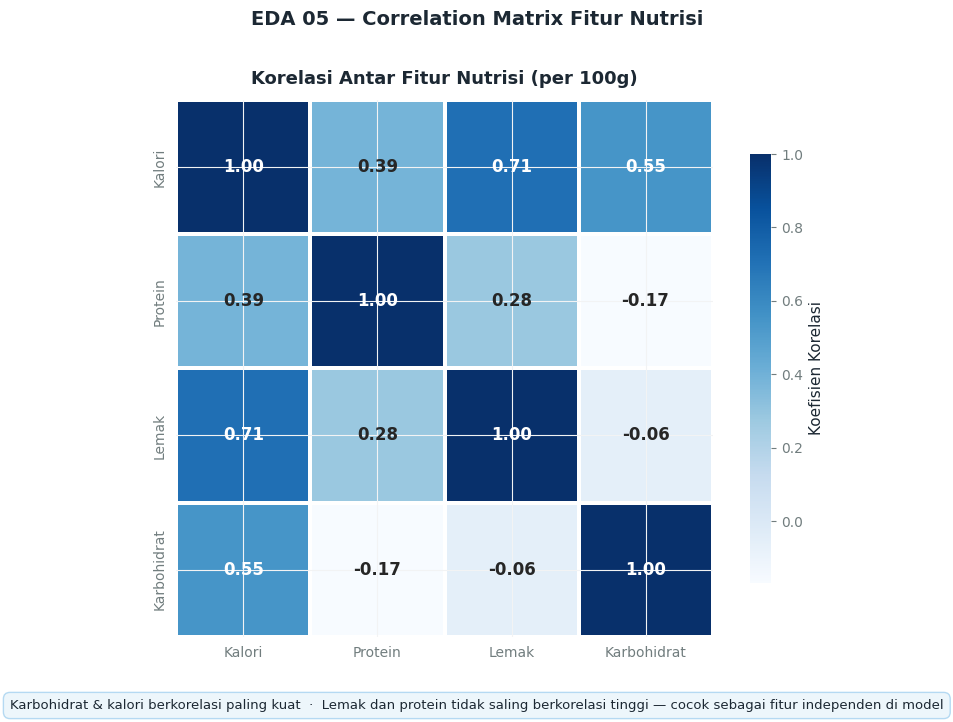

In [55]:
corr_cols   = ['calories_100g','protein_100g','fat_100g','carbohydrate_100g']
corr_labels = ['Kalori', 'Protein', 'Lemak', 'Karbohidrat']

corr = fm[corr_cols].corr()
corr.index   = corr_labels
corr.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.suptitle('EDA 05 — Correlation Matrix Fitur Nutrisi',
             fontsize=14, fontweight='bold', y=1.02)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=1.5, linecolor='white',
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Korelasi Antar Fitur Nutrisi (per 100g)', fontweight='bold', pad=12)
ax.tick_params(left=False, bottom=False)

add_insight_bar(fig,
    'Karbohidrat & kalori berkorelasi paling kuat  ·  '
    'Lemak dan protein tidak saling berkorelasi tinggi — cocok sebagai fitur independen di model',
    y=-0.06)

plt.tight_layout()
plt.savefig('eda_05_correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## Ringkasan

In [56]:
print('RINGKASAN EDA')
print('-' * 65)

print(f"""
FOOD MASTER CLEAN
  Total entri          : {len(fm):,} makanan
  Kalori median        : {fm['calories_100g'].median():.0f} kcal/100g
  Kalori rata-rata     : {fm['calories_100g'].mean():.0f} kcal/100g
  Rentang kalori       : {fm['calories_100g'].min():.0f} – {fm['calories_100g'].max():.0f} kcal
  Zero calorie flag    : {fm['zero_calorie_flag'].sum()} entri (flagged, tidak dihapus)
  Inconsistent flag    : {fm['calorie_inconsistent_flag'].sum()} entri (selisih >50 kcal dari makro)
  Image coverage       : {(fm['image_url']!='not_available').sum():,}/{len(fm):,} = {(fm['image_url']!='not_available').mean()*100:.0f}%

USER PROFILE SCHEMA
  Total baris          : {len(up)} (synthetic demo — bukan data produksi)
  Gender               : {up['gender'].value_counts().to_dict()}
  Goal distribution    : {up['goal'].value_counts().to_dict()}
  BMR range            : {up['bmr'].min():.0f} – {up['bmr'].max():.0f} kcal/hari
  TDEE range           : {up['tdee'].min():.0f} – {up['tdee'].max():.0f} kcal/hari
  allergy_vector       : placeholder 8 kategori (gluten, dairy, nuts, peanut,
                         seafood, egg, soy, other)
""")

RINGKASAN EDA
-----------------------------------------------------------------

FOOD MASTER CLEAN
  Total entri          : 1,332 makanan
  Kalori median        : 144 kcal/100g
  Kalori rata-rata     : 199 kcal/100g
  Rentang kalori       : 0 – 884 kcal
  Zero calorie flag    : 1 entri (flagged, tidak dihapus)
  Inconsistent flag    : 58 entri (selisih >50 kcal dari makro)
  Image coverage       : 1,332/1,332 = 100%

USER PROFILE SCHEMA
  Total baris          : 100 (synthetic demo — bukan data produksi)
  Gender               : {'Male': 57, 'Female': 43}
  Goal distribution    : {'maintain': 36, 'cutting': 33, 'bulking': 31}
  BMR range            : 971 – 2005 kcal/hari
  TDEE range           : 1336 – 3231 kcal/hari
  allergy_vector       : placeholder 8 kategori (gluten, dairy, nuts, peanut,
                         seafood, egg, soy, other) 

